## A Multi-Year Risk Assessment of SIGMET Evolution in Ujung Pandang FIR Airspace: Reconstructing Fragmented Spatiotemporal Hazards for Aviation Decision Support (2019–2025)

## Figure 1

Peta berhasil disimpan: D:\MAGANG STAMET HASANUDDIN\Peta_FIR_Indonesia.png


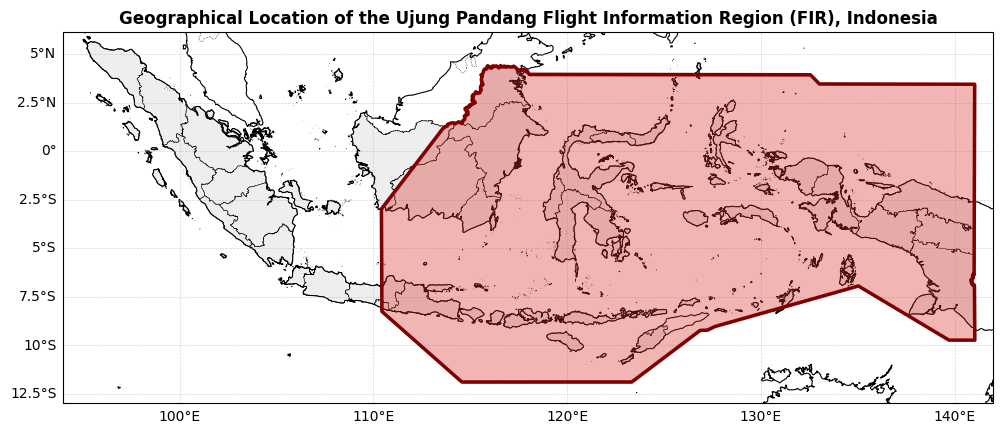

In [1]:
# ==========================================
# 0. IMPORT
# ==========================================
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import zipfile
import tempfile
import os

# ==========================================
# 1. LOAD FIR UJUNG PANDANG (KMZ)
# ==========================================
kmz_path = r"D:\MAGANG STAMET HASANUDDIN\POLIGON FIR UJUNG PANDANG.kmz"

def load_fir_kmz(path):
    tmp_dir = tempfile.mkdtemp()
    with zipfile.ZipFile(path, "r") as kmz:
        kmz.extractall(tmp_dir)
    for root, _, files in os.walk(tmp_dir):
        for file in files:
            if file.endswith(".kml"):
                return gpd.read_file(os.path.join(root, file)).to_crs(epsg=4326)
    raise FileNotFoundError("KML tidak ditemukan")

fir_gdf = load_fir_kmz(kmz_path)

# ==========================================
# 2. LOAD SHAPEFILE PROVINSI
# ==========================================
shp_path = r"C:\Users\USER\Downloads\BATAS WILAYAH KELURAHAN-DESA 10K\Batas_Wilayah_KelurahanDesa_10K_AR.shp"

gdf = gpd.read_file(shp_path)[["WADMPR", "geometry"]]
gdf_prov = gdf.dissolve(by="WADMPR").to_crs(epsg=4326)

# ==========================================
# 3. PLOT PETA INDONESIA + FIR
# ==========================================
fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Extent seluruh Indonesia
ax.set_extent([94, 142, -12, 6])

# ==========================================
# 4. BASE MAP (INDONESIA)
# ==========================================
gdf_prov.plot(
    ax=ax,
    facecolor="#eeeeee",     # abu-abu muda
    edgecolor="black",
    linewidth=0.4,
    transform=ccrs.PlateCarree(),
    zorder=1
)

# ==========================================
# 5. FIR HIGHLIGHT
# ==========================================
fir_gdf.plot(
    ax=ax,
    facecolor="#d73027",
    edgecolor="#7f0000",
    linewidth=1.8,
    alpha=0.35,
    transform=ccrs.PlateCarree(),
    zorder=3
)

# Boundary FIR (biar tegas)
fir_gdf.boundary.plot(
    ax=ax,
    edgecolor="#7f0000",
    linewidth=2.5,
    transform=ccrs.PlateCarree(),
    zorder=4
)

# ==========================================
# 6. TAMBAHAN VISUAL
# ==========================================
ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# ==========================================
# 7. JUDUL
# ==========================================
plt.title(
    "Geographical Location of the Ujung Pandang Flight Information Region (FIR), Indonesia",
    fontsize=12,
    fontweight="bold"
)

# ==========================================
# 8. SIMPAN
# ==========================================
out_path = r"D:\MAGANG STAMET HASANUDDIN\Peta_FIR_Indonesia.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

print("Peta berhasil disimpan:", out_path)

plt.show()

## Figure 4

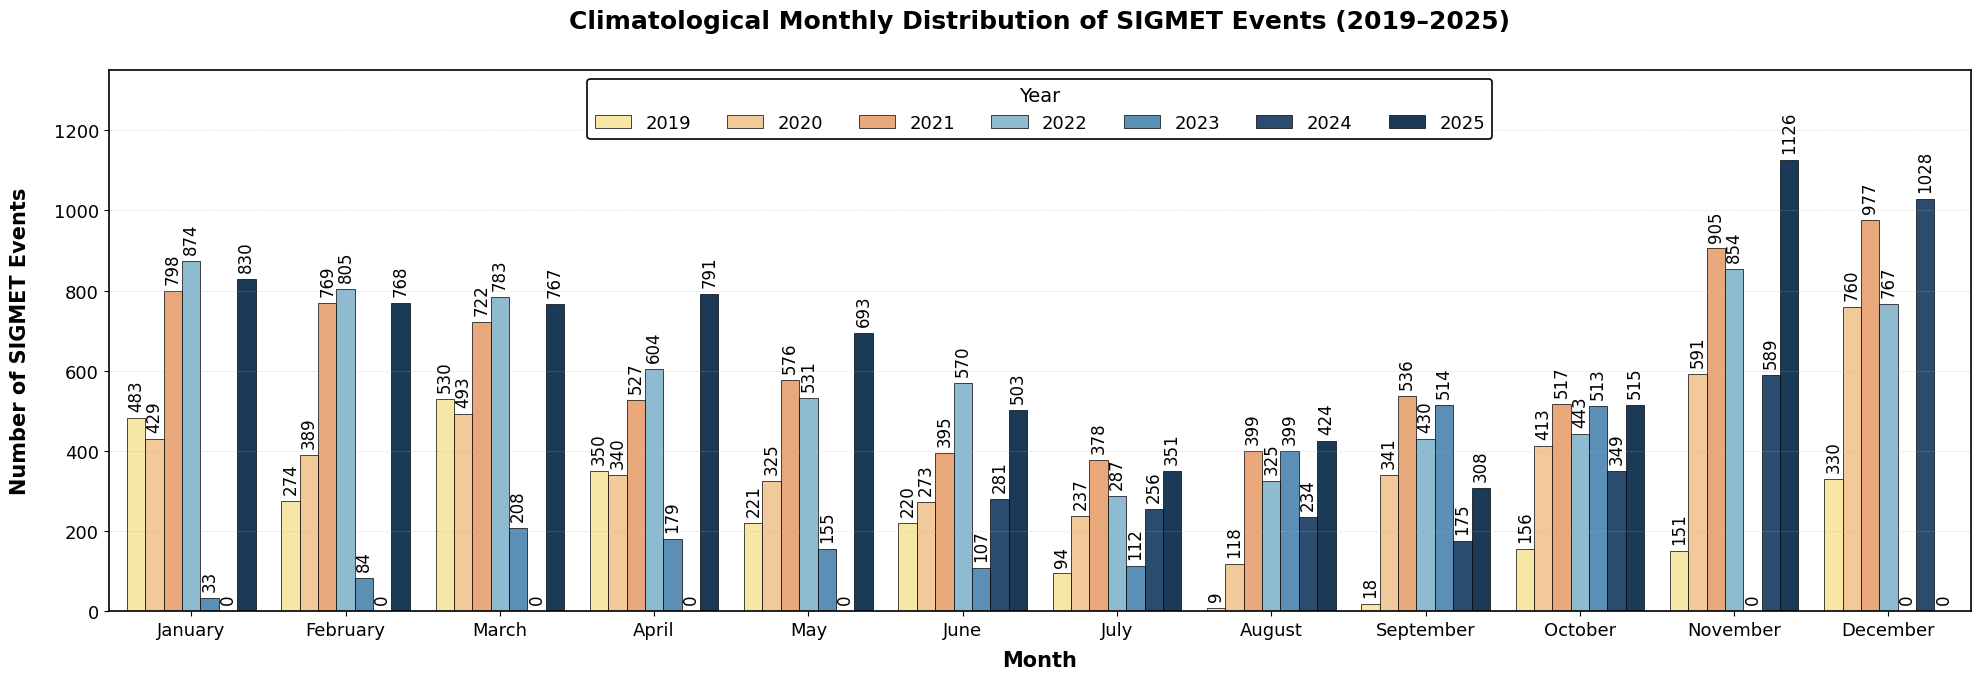

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# =========================
# SETTING GLOBAL (paper style)
# =========================
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13
})

# =========================
# LOAD DATA
# =========================
file_path = r"C:\Users\USER\Downloads\Data SIGMET (2).xlsx"
save_dir = os.path.dirname(file_path)
save_path = os.path.join(save_dir, "sigmet_monthly_distribution.png")

xls = pd.ExcelFile(file_path)

data_list = []

bulan_map = {
    "Januari": "January",
    "Februari": "February",
    "Maret": "March",
    "April": "April",
    "Mei": "May",
    "Juni": "June",
    "Juli": "July",
    "Agustus": "August",
    "September": "September",
    "Oktober": "October",
    "November": "November",
    "Desember": "December"
}

# =========================
# EXTRACT DATA
# =========================
for sheet in xls.sheet_names:
    try:
        bulan, tahun = sheet.split("_")

        df = pd.read_excel(xls, sheet_name=sheet)

        # cari kolom 'code' (case insensitive)
        code_col = [c for c in df.columns if c.lower() == "code"]

        if code_col:
            jumlah = df[code_col[0]].nunique()
        else:
            jumlah = 0

        data_list.append({
            "bulan": bulan.strip(),
            "tahun": int(tahun.strip()),
            "jumlah": jumlah
        })

    except Exception as e:
        print(f"Skip sheet: {sheet} ({e})")

# =========================
# PREPARE DATA
# =========================
data = pd.DataFrame(data_list)

# convert to English month
data["bulan"] = data["bulan"].map(bulan_map)

bulan_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

data["bulan"] = pd.Categorical(
    data["bulan"],
    categories=bulan_order,
    ordered=True
)

pivot = data.pivot(
    index="bulan",
    columns="tahun",
    values="jumlah"
).fillna(0)

# =========================
# PLOT
# =========================
fig, ax = plt.subplots(figsize=(20,7))
ax.margins(x=0.01)

x = np.arange(len(pivot.index)) * 1.2
n_tahun = len(pivot.columns)

width = 1 / n_tahun


colors = [
    "#F6E7A6",
    "#F2C99B",
    "#E8A87C",
    "#8FBBD1",
    "#5C8FB5",
    "#2B4C6F",
    "#1B3A57"  
]

bars_all = []

for i, tahun in enumerate(pivot.columns):
    bars = ax.bar(
        x + i*width - (n_tahun-1)*width/2,
        pivot[tahun],
        width=width,
        label=tahun,
        color=colors[i % len(colors)],
        edgecolor='black',
        linewidth=0.5
    )
    bars_all.append(bars)

# =========================
# BAR LABEL
# =========================
for bars in bars_all:
    ax.bar_label(
        bars,
        padding=5,
        fontsize=12,
        rotation=90
    )

# =========================
# LABEL & TITLE
# =========================
ax.set_xlabel("Month", fontsize=15, labelpad=8, weight='bold')
ax.set_ylabel("Number of SIGMET Events", fontsize=15, labelpad=17, weight='bold')

ax.set_title(
    "Climatological Monthly Distribution of SIGMET Events (2019–2025)",
    fontsize=18,
    weight='bold',
    pad=30
)

# =========================
# X TICKS
# =========================
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=0, fontsize=13)

# =========================
# LEGEND
# =========================
leg = ax.legend(
    title="Year",
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0),
    ncol=len(pivot.columns),
    frameon=True,
    edgecolor='black',
    framealpha=1
)

leg.get_title().set_fontsize(14)
leg.get_frame().set_linewidth(1.2)

# =========================
# STYLE
# =========================
ax.set_facecolor("white")
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color('black')

ax.set_ylim(0, pivot.to_numpy().max() * 1.2)

plt.subplots_adjust(top=0.85)
plt.tight_layout()

# =========================
# SAVE
# =========================
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

## Figure 5

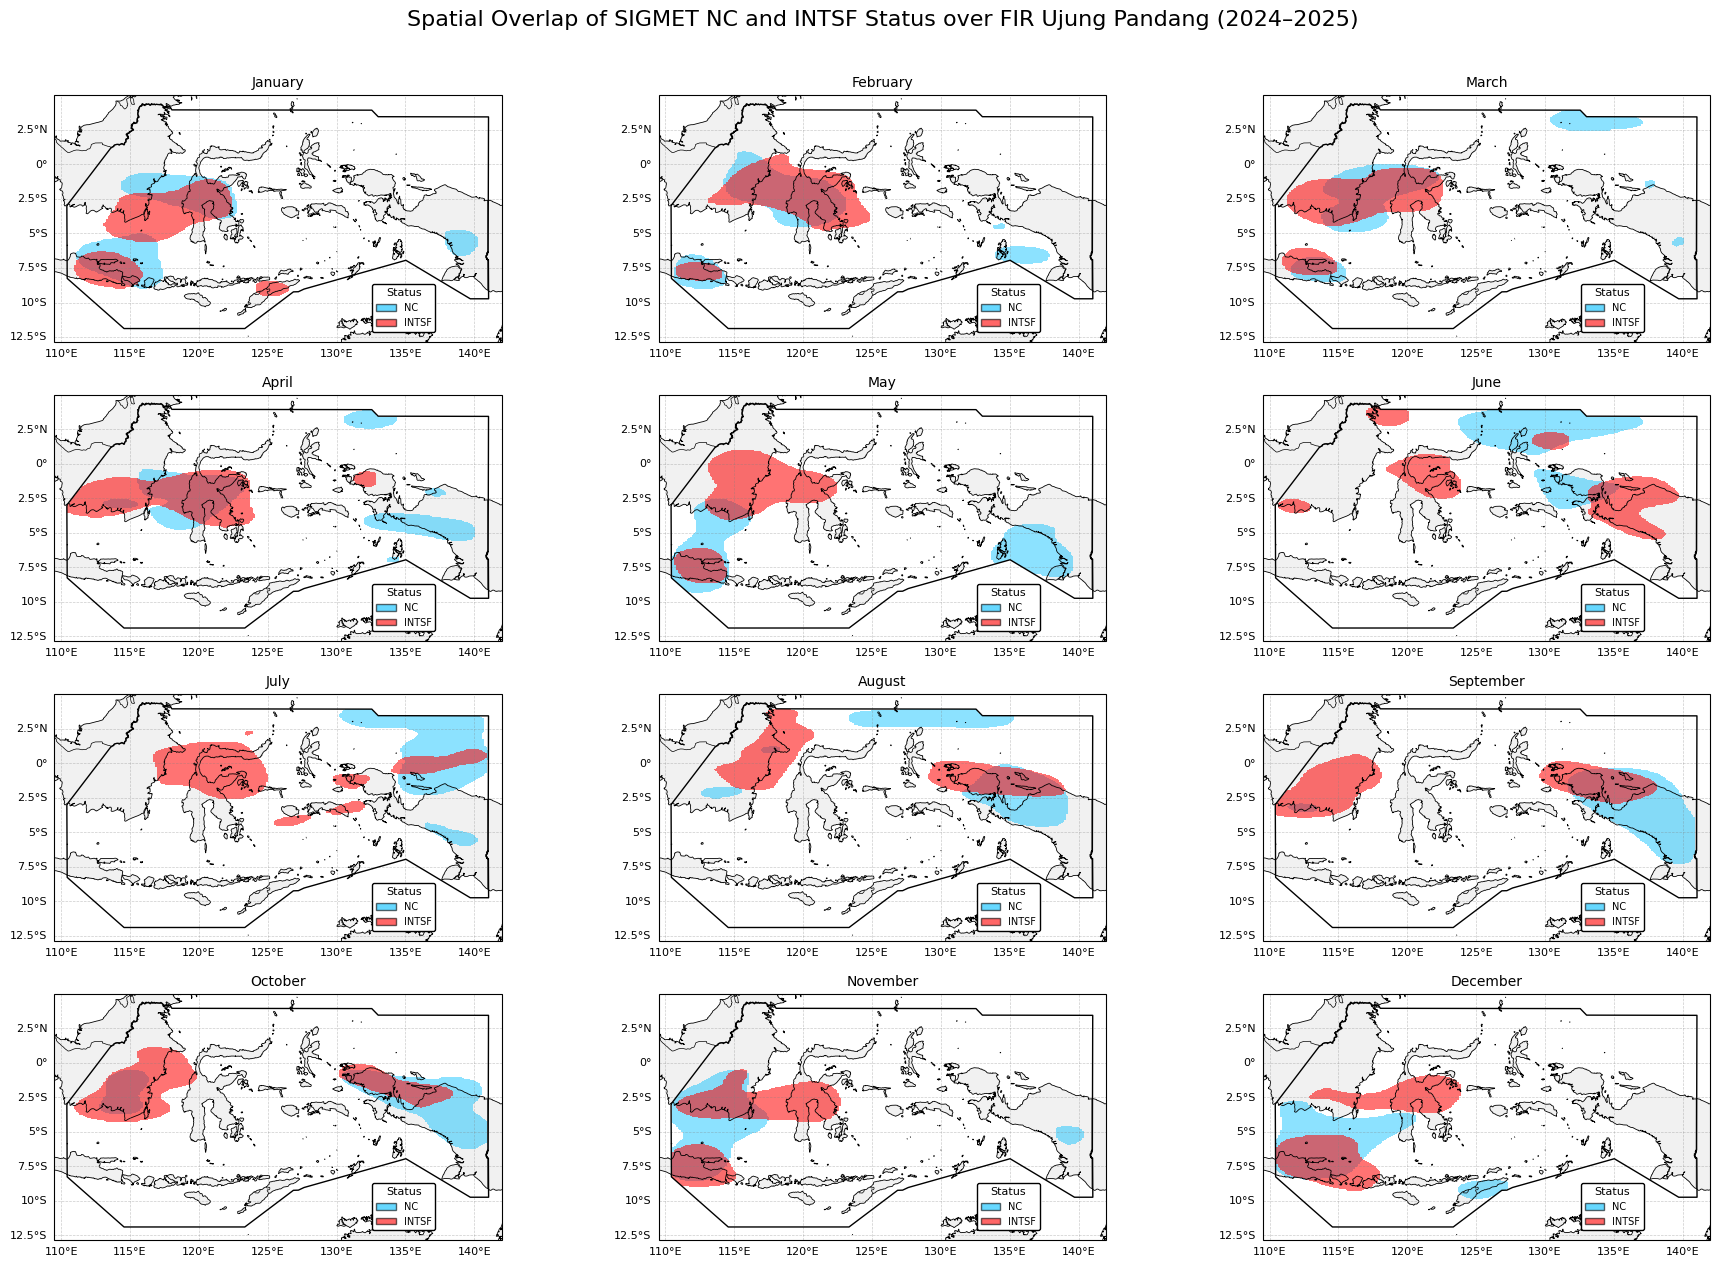

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

from scipy.stats import gaussian_kde
import zipfile
import tempfile
import os
from shapely import contains_xy
from matplotlib.patches import Patch


# ======================
# LOAD DATA
# ======================
file_path = r"C:\Users\USER\Downloads\Data SIGMET (2).xlsx"
all_sheets = pd.read_excel(file_path, sheet_name=None)

bulan_map = {
    "Januari": "January", "Februari": "February", "Maret": "March",
    "April": "April", "Mei": "May", "Juni": "June",
    "Juli": "July", "Agustus": "August", "September": "September",
    "Oktober": "October", "November": "November", "Desember": "December"
}

df_list = []

for sheet_name, df in all_sheets.items():
    df = df.copy()
    df.columns = df.columns.str.strip()

    try:
        bulan_id, tahun = sheet_name.split("_")
        tahun = int(tahun)
    except:
        continue

    if tahun < 2024 or tahun > 2025:
        continue

    df["Bulan"] = bulan_map.get(bulan_id, bulan_id)
    df["Tahun"] = tahun

    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)


# ======================
# FIR UJUNG PANDANG
# ======================
kmz_path = r"D:\MAGANG STAMET HASANUDDIN\POLIGON FIR UJUNG PANDANG.kmz"

def load_kmz(path):
    tmp = tempfile.mkdtemp()
    with zipfile.ZipFile(path, "r") as kmz:
        kmz.extractall(tmp)

    for r, _, f in os.walk(tmp):
        for file in f:
            if file.endswith(".kml"):
                return gpd.read_file(os.path.join(r, file))

fir_gdf = load_kmz(kmz_path).to_crs(epsg=4326)
fir_union = fir_gdf.geometry.union_all()


# ======================
# DOMAIN
# ======================
min_lat, max_lat = -12.8, 5
min_lon, max_lon = 109.5, 142

bulan_list = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]


# ======================
# FIGURE
# ======================
fig = plt.figure(figsize=(18, 14))
nrows, ncols = 4, 3


# ======================
# KDE FUNCTION
# ======================
def build_kde(df):
    pts = []

    for code in df["Code"].unique():
        dfc = df[df["Code"] == code]

        lat = dfc["Latitude"].values
        lon = dfc["Longitude"].values

        mask = ~np.isnan(lat) & ~np.isnan(lon)
        lat = lat[mask]
        lon = lon[mask]

        if len(lat) < 3:
            continue

        pts.append(np.column_stack([lon, lat]))

    if len(pts) == 0:
        return None

    pts = np.vstack(pts)
    kde = gaussian_kde(pts.T, bw_method=0.2)

    lon_grid = np.linspace(min_lon, max_lon, 200)
    lat_grid = np.linspace(min_lat, max_lat, 200)
    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

    grid = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])
    z = kde(grid).reshape(lon_mesh.shape)

    z = z / np.max(z)
    return lon_mesh, lat_mesh, z


# ======================
# LOOP BULAN
# ======================
for i, bulan in enumerate(bulan_list):

    ax = plt.subplot(nrows, ncols, i+1, projection=ccrs.PlateCarree())

    df_bulan = data[data["Bulan"] == bulan]

    df_nc = df_bulan[df_bulan["Status"].str.upper() == "NC"]
    df_int = df_bulan[df_bulan["Status"].str.upper() == "INTSF"]

    res_nc = build_kde(df_nc)
    res_int = build_kde(df_int)

    if res_nc is None and res_int is None:
        ax.set_title(f"{bulan}\nNo Data", fontsize=10)
        continue

    # ======================
    # GRID
    # ======================
    if res_nc:
        lon_mesh, lat_mesh, z_nc = res_nc
    else:
        lon_mesh, lat_mesh, _ = res_int
        z_nc = np.zeros_like(lon_mesh)

    if res_int:
        _, _, z_int = res_int
    else:
        z_int = np.zeros_like(lon_mesh)

    # ======================
    # FIR MASK
    # ======================
    mask = contains_xy(fir_union, lon_mesh, lat_mesh)
    z_nc = np.where(mask, z_nc, np.nan)
    z_int = np.where(mask, z_int, np.nan)

    # ======================
    # CORE ONLY
    # ======================
    if np.nanmax(z_nc) > 0:
        nc_thr = np.nanpercentile(z_nc, 90)
        z_nc_core = np.where(z_nc >= nc_thr, z_nc, np.nan)
    else:
        z_nc_core = z_nc

    if np.nanmax(z_int) > 0:
        int_thr = np.nanpercentile(z_int, 90)
        z_int_core = np.where(z_int >= int_thr, z_int, np.nan)
    else:
        z_int_core = z_int

    # ======================
    # BASE MAP
    # ======================
    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    ax.coastlines(resolution="10m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # ======================
    # GRIDLINES
    # ======================
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.4,
        linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = True
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    # ======================
    # NC CORE
    # ======================
    if res_nc:
        ax.contourf(
            lon_mesh, lat_mesh, z_nc_core,
            levels=[0.0001, np.nanmax(z_nc_core)],
            colors="deepskyblue",
            alpha=0.45,
            transform=ccrs.PlateCarree()
        )

    # ======================
    # INTSF CORE
    # ======================
    if res_int:
        ax.contourf(
            lon_mesh, lat_mesh, z_int_core,
            levels=[0.0001, np.nanmax(z_int_core)],
            colors="red",
            alpha=0.55,
            transform=ccrs.PlateCarree()
        )

    # ======================
    # FIR BOUNDARY
    # ======================
    fir_gdf.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1,
        transform=ccrs.PlateCarree()
    )

    ax.set_extent([min_lon, max_lon, min_lat, max_lat])
    ax.set_title(bulan, fontsize=10)

    # ======================
    # LEGEND GLOBAL
    # ======================
    
    legend_elements = [
    Patch(facecolor="deepskyblue", edgecolor="black", alpha=0.6, label="NC"),
    Patch(facecolor="red", edgecolor="black", alpha=0.6, label="INTSF")
    ]

    ax.legend(
        handles=legend_elements,
        loc='lower left',
        bbox_to_anchor=(0.70, 0.02),
        fontsize=7,
        title="Status",
        title_fontsize=8,
        framealpha=1,
        edgecolor='black'
    )


# ======================
# TITLE
# ======================
plt.suptitle(
    "Spatial Overlap of SIGMET NC and INTSF Status over FIR Ujung Pandang (2024–2025)", 
    fontsize=16
)

plt.subplots_adjust(
    left=0.04,
    right=0.96,
    top=0.92,
    bottom=0.10,
    wspace=0.35,   
    hspace=0.20
)

plt.show()

## Figure 6

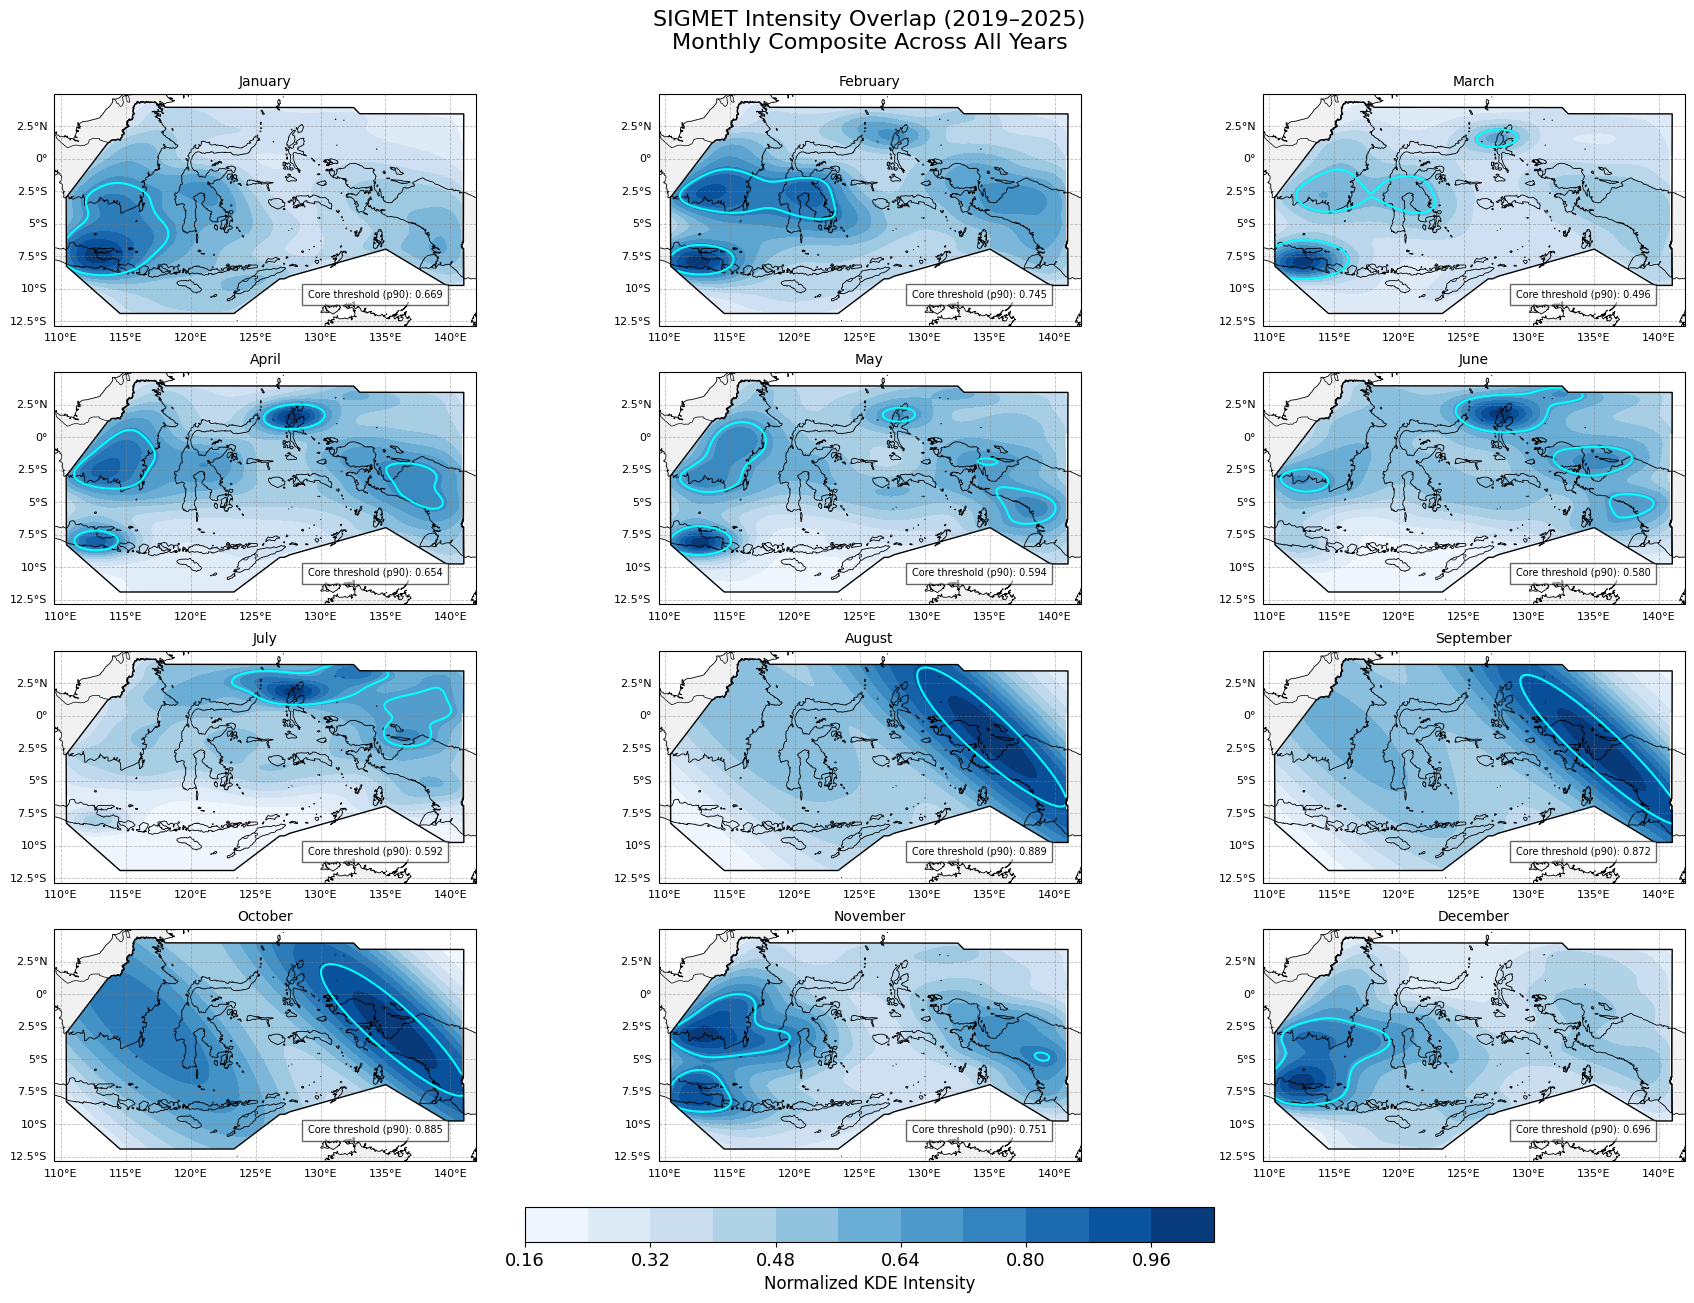

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

from scipy.stats import gaussian_kde
import zipfile
import tempfile
import os
from shapely import contains_xy


# ======================
# LOAD ALL SHEETS
# ======================
file_path = r"C:\Users\USER\Downloads\Data SIGMET (2).xlsx"

all_sheets = pd.read_excel(file_path, sheet_name=None)

df_list = []

bulan_map = {
    "Januari": "January",
    "Februari": "February",
    "Maret": "March",
    "April": "April",
    "Mei": "May",
    "Juni": "June",
    "Juli": "July",
    "Agustus": "August",
    "September": "September",
    "Oktober": "October",
    "November": "November",
    "Desember": "December"
}

for sheet_name, df in all_sheets.items():
    df = df.copy()
    df.columns = df.columns.str.strip()

    bulan_id = sheet_name.split("_")[0]
    df["Bulan"] = bulan_map.get(bulan_id, bulan_id)

    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)


# ======================
# LOAD FIR KMZ
# ======================
kmz_path = r"D:\MAGANG STAMET HASANUDDIN\POLIGON FIR UJUNG PANDANG.kmz"

def load_fir_kmz(path):
    tmp_dir = tempfile.mkdtemp()

    with zipfile.ZipFile(path, "r") as kmz:
        kmz.extractall(tmp_dir)

    for root, _, files in os.walk(tmp_dir):
        for file in files:
            if file.endswith(".kml"):
                return gpd.read_file(os.path.join(root, file))

fir_gdf = load_fir_kmz(kmz_path).to_crs(epsg=4326)

fir_union = fir_gdf.geometry.union_all()


# ======================
# DOMAIN
# ======================
min_lat, max_lat = -12.8, 5
min_lon, max_lon = 109.5, 142


bulan_list = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]


# ======================
# FIGURE
# ======================
fig = plt.figure(figsize=(18, 14))
nrows, ncols = 4, 3

mappable = None  # untuk colorbar global


# ======================
# LOOP
# ======================
for i, bulan in enumerate(bulan_list):

    ax = plt.subplot(nrows, ncols, i+1, projection=ccrs.PlateCarree())

    df_bulan = data[data["Bulan"] == bulan]

    # ======================
    # POINT EXTRACTION
    # ======================
    points = []

    for code in df_bulan["Code"].unique():
        dfc = df_bulan[df_bulan["Code"] == code]

        lat = dfc["Latitude"].values
        lon = dfc["Longitude"].values

        mask = ~np.isnan(lat) & ~np.isnan(lon)
        lat = lat[mask]
        lon = lon[mask]

        if len(lat) < 3:
            continue

        points.append(np.column_stack([lon, lat]))

    if len(points) == 0:
        ax.set_title(f"{bulan}\nNo Data", fontsize=10)
        continue

    points = np.vstack(points)
    x, y = points[:, 0], points[:, 1]

    # ======================
    # KDE
    # ======================
    kde = gaussian_kde(np.vstack([x, y]), bw_method=0.2)

    lon_grid = np.linspace(min_lon, max_lon, 200)
    lat_grid = np.linspace(min_lat, max_lat, 200)

    lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

    grid_coords = np.vstack([lon_mesh.ravel(), lat_mesh.ravel()])
    z = kde(grid_coords).reshape(lon_mesh.shape)

    z = z / np.max(z)

    # ======================
    # FIR MASK
    # ======================
    fir_mask = contains_xy(fir_union, lon_mesh, lat_mesh)
    z = np.where(fir_mask, z, np.nan)

    # ======================
    # THRESHOLD
    # ======================
    threshold = np.nanpercentile(z, 90)

    # ======================
    # MAP STYLE
    # ======================
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.6,
        color='gray',
        alpha=0.5,
        linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = True
    gl.bottom_labels = True
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=1)
    ax.coastlines(resolution="10m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    heat = ax.contourf(
        lon_mesh, lat_mesh, z,
        levels=12,
        cmap="Blues",
        transform=ccrs.PlateCarree()
    )

    ax.contour(
        lon_mesh, lat_mesh, z,
        levels=[threshold],
        colors="cyan",
        linewidths=1.5,
        transform=ccrs.PlateCarree()
    )

    fir_gdf.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1,
        transform=ccrs.PlateCarree()
    )

    ax.text(
        min_lon + (max_lon - min_lon) * 0.60,
        min_lat + (max_lat - min_lat) * 0.12,
        f"Core threshold (p90): {threshold:.3f}",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor='black'),
        fontsize=7
    )

    ax.set_extent([min_lon, max_lon, min_lat, max_lat])
    ax.set_title(bulan, fontsize=10)

    mappable = heat  # simpan untuk colorbar


# ======================
# GLOBAL TITLE
# ======================
plt.suptitle(
    "SIGMET Intensity Overlap (2019–2025)\nMonthly Composite Across All Years",
    fontsize=16
)

plt.subplots_adjust(
    left=0.04,
    right=0.96,
    top=0.92,
    bottom=0.10,
    wspace=0.35,   # ⬅️ ini yang bikin antar kolom lebih lega
    hspace=0.20
)

# ======================
# COLORBAR GLOBAL
# ======================
cbar = fig.colorbar(
    mappable,
    ax=fig.axes,
    orientation='horizontal',
    fraction=0.03,
    pad=0.04
)

cbar.set_label("Normalized KDE Intensity", fontsize=12)

plt.show()

## Figure 7

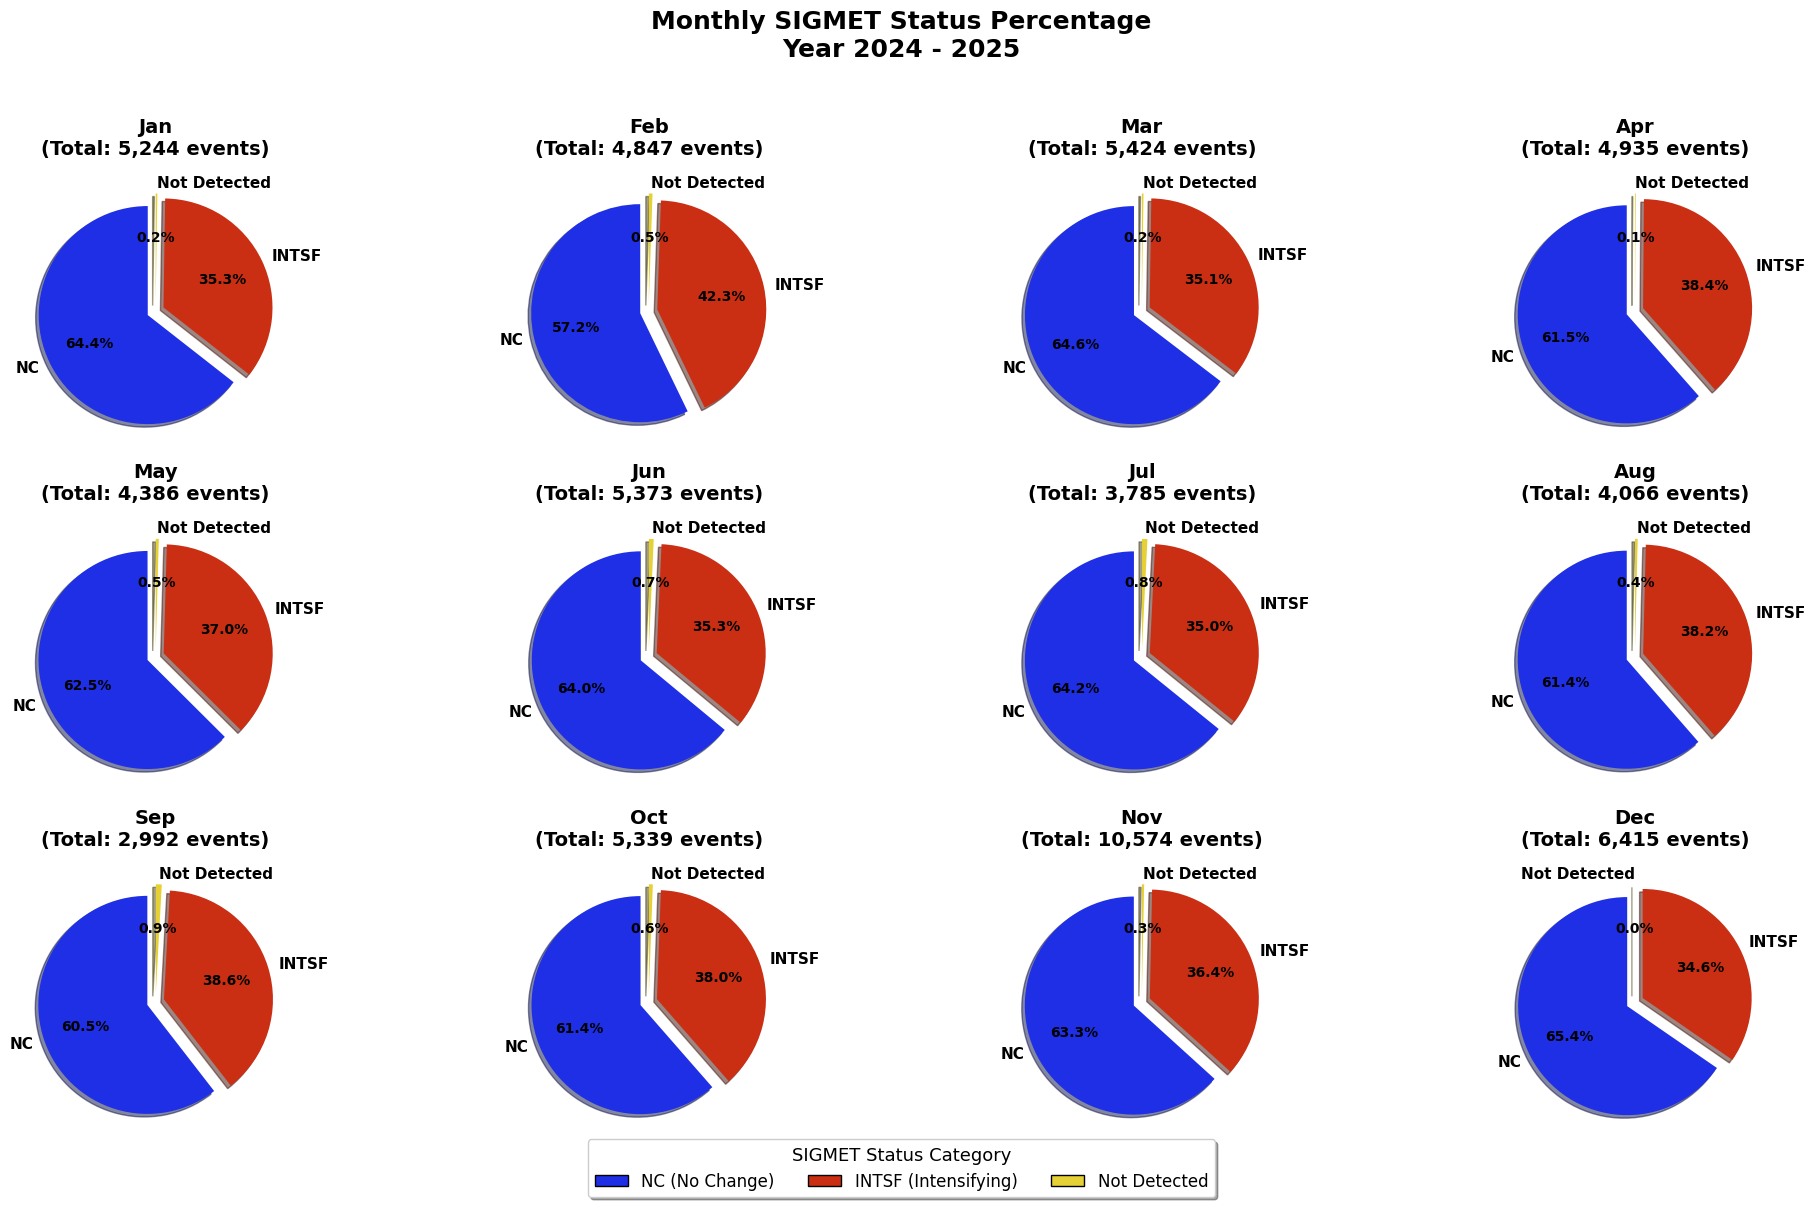

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ================================
# 1. PATH FILE
# ================================
file_path = r"C:\Users\LENOVO\Documents\Tugaslah Pokoknya\Penerbangan\Data SIGMET.xlsx"

# ================================
# 2. SETUP
# ================================
excel_file = pd.ExcelFile(file_path)
sheet_names = excel_file.sheet_names

month_map = {
    'Januari': 'Jan', 'Februari': 'Feb', 'Maret': 'Mar', 'April': 'Apr',
    'Mei': 'May', 'Juni': 'Jun', 'Juli': 'Jul', 'Agustus': 'Aug',
    'September': 'Sep', 'Oktober': 'Oct', 'November': 'Nov', 'Desember': 'Dec'
}

months_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

data_monthly = {month: {'NC': 0, 'INTSF': 0, 'Not Detected': 0} for month in months_order}

# Warna baru: Merah dan Biru (tema lebih kuat)
colors = ["#1E2FE5", "#CA2F14", "#E5D035"]   # Biru terang, Biru gelap, Merah

# ================================
# 3. PROSES DATA 2024 & 2025
# ================================
for sheet in sheet_names:
    if not ('2024' in sheet or '2025' in sheet):
        continue
    
    try:
        month_id = sheet.split('_')[0].strip()
        if month_id not in month_map:
            continue
        month = month_map[month_id]
        
        df = pd.read_excel(file_path, sheet_name=sheet, header=0)
        df.columns = df.columns.str.strip()
        
        # Deteksi kolom status
        status_col = None
        for col in df.columns:
            if str(col).upper() in ['NC', 'INTSF', 'STATUS', 'TREND']:
                status_col = col
                break
        if status_col is None and len(df.columns) >= 7:
            status_col = df.columns[6]
        
        if status_col is None:
            continue
            
        df[status_col] = df[status_col].astype(str).str.strip().str.upper()
        
        nc_count = (df[status_col] == 'NC').sum()
        intsf_count = (df[status_col] == 'INTSF').sum()
        unknown_count = len(df) - nc_count - intsf_count
        
        data_monthly[month]['NC'] += nc_count
        data_monthly[month]['INTSF'] += intsf_count
        data_monthly[month]['Not Detected'] += unknown_count
        
    except:
        continue

# ================================
# 4. BUAT FIGURE YANG DIPERCANTIK (Bahasa Inggris)
# ================================
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
axes = axes.flatten()

for i, month in enumerate(months_order):
    ax = axes[i]
    values = data_monthly[month]
    total = sum(values.values())
    
    if total == 0:
        ax.text(0.5, 0.5, f'No Data\n{month}', 
                ha='center', va='center', fontsize=14, color='gray')
        ax.axis('off')
        continue
    
    labels = ['NC', 'INTSF', 'Not Detected']
    sizes = [values['NC'], values['INTSF'], values['Not Detected']]
    
    wedges, texts, autotexts = ax.pie(
        sizes, 
        labels=labels, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=colors,
        shadow=True,
        explode=(0.08, 0.08, 0.08),
        textprops={'fontsize': 11, 'weight': 'bold'}
    )
    
    for autotext in autotexts:
        autotext.set_fontsize(10)
        autotext.set_weight('bold')
    
    ax.set_title(f'{month}\n(Total: {total:,} events)', 
                 fontsize=14, pad=15, fontweight='bold')

# Hilangkan subplot kosong
for j in range(len(months_order), len(axes)):
    axes[j].axis('off')

# ==================== LEGEND (COLORBAR) DI BAWAH ====================
legend_elements = [
    Patch(facecolor=colors[0], edgecolor='black', label='NC (No Change)'),
    Patch(facecolor=colors[1], edgecolor='black', label='INTSF (Intensifying)'),
    Patch(facecolor=colors[2], edgecolor='black', label='Not Detected')
]

fig.legend(handles=legend_elements, 
           title='SIGMET Status Category',
           title_fontsize=13,
           fontsize=12,
           loc='lower center',
           bbox_to_anchor=(0.5, 0.04),
           ncol=3,
           frameon=True,
           fancybox=True,
           shadow=True)

# Judul Utama
plt.suptitle('Monthly SIGMET Status Percentage\nYear 2024 - 2025', 
             fontsize=18, fontweight='bold', y=0.96)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])
plt.show()

## Figure 8

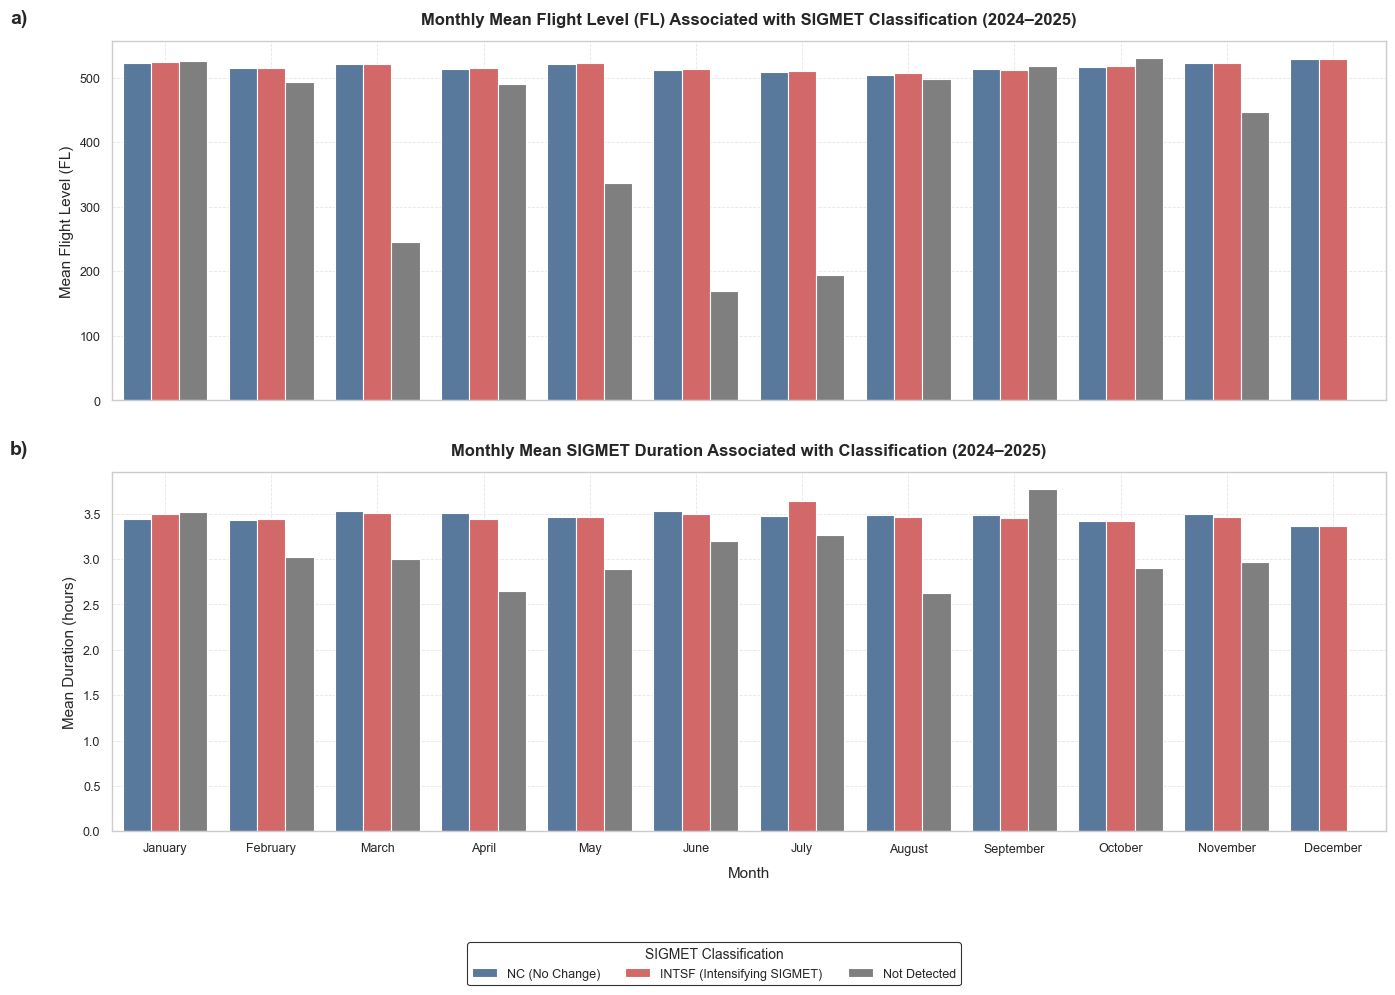

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# STYLE (journal-ready)
# ======================
sns.set_theme(style="whitegrid", context="paper")

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})

# ======================
# LOAD DATA
# ======================
file_path = r"C:\Users\USER\Downloads\Data SIGMET (2).xlsx"
all_sheets = pd.read_excel(file_path, sheet_name=None)

bulan_map = {
    "Januari": "January", "Februari": "February", "Maret": "March",
    "April": "April", "Mei": "May", "Juni": "June",
    "Juli": "July", "Agustus": "August", "September": "September",
    "Oktober": "October", "November": "November", "Desember": "December"
}

df_list = []

for sheet_name, df in all_sheets.items():
    try:
        bulan_id, tahun = sheet_name.split("_")
        tahun = int(tahun)
    except:
        continue

    if tahun not in [2024, 2025]:
        continue

    df = df.copy()
    df.columns = df.columns.str.strip()
    df["Bulan"] = bulan_map.get(bulan_id, bulan_id)

    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)

# ======================
# CLEAN DATA
# ======================
data["FL WITHOUT"] = pd.to_numeric(data["FL WITHOUT"], errors="coerce")
data["Konversi"] = pd.to_numeric(data["Konversi"], errors="coerce")

data["Status"] = data["Status"].astype(str).str.strip().str.upper()

valid_status = ["NC", "INTSF", "TIDAK TERDETEKSI"]
data = data[data["Status"].isin(valid_status)]

data = data.dropna(subset=["FL WITHOUT", "Konversi", "Bulan"])

# ======================
# ORDER MONTH
# ======================
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

data["Bulan"] = pd.Categorical(data["Bulan"], categories=month_order, ordered=True)

# ======================
# AGGREGATION
# ======================
plot_fl = data.groupby(["Bulan", "Status"], observed=False)["FL WITHOUT"].mean().reset_index()
plot_dur = data.groupby(["Bulan", "Status"], observed=False)["Konversi"].mean().reset_index()

# ======================
# LABEL
# ======================
status_map = {
    "NC": "NC (No Change)",
    "INTSF": "INTSF (Intensifying SIGMET)",
    "TIDAK TERDETEKSI": "Not Detected"
}

plot_fl["Status_EN"] = plot_fl["Status"].map(status_map)
plot_dur["Status_EN"] = plot_dur["Status"].map(status_map)

# ======================
# PALETTE
# ======================
palette = {
    "NC (No Change)": "#4C78A8",
    "INTSF (Intensifying SIGMET)": "#E45756",
    "Not Detected": "#7F7F7F"
}

# ======================
# FIGURE
# ======================
fig, axes = plt.subplots(
    2, 1,
    figsize=(14, 10),
    sharex=True,
    gridspec_kw={'hspace': 0.2}
)

# ======================
# (a) FL
# ======================
sns.barplot(
    data=plot_fl,
    x="Bulan",
    y="FL WITHOUT",
    hue="Status_EN",
    hue_order=list(palette.keys()),
    palette=palette,
    ax=axes[0]
)

axes[0].set_title(
    "Monthly Mean Flight Level (FL) Associated with SIGMET Classification (2024–2025)",
    fontweight="bold",
    pad=12
)

axes[0].set_ylabel("Mean Flight Level (FL)")
axes[0].set_xlabel("")  # ❗ tidak pakai Month di plot atas
axes[0].tick_params(axis='x', labelbottom=False)  # ❗ sembunyikan label bulan

axes[0].text(-0.08, 1.05, "a)", transform=axes[0].transAxes,
             fontsize=14, fontweight="bold")

axes[0].grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

for spine in axes[0].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

# ======================
# (b) Duration
# ======================
sns.barplot(
    data=plot_dur,
    x="Bulan",
    y="Konversi",
    hue="Status_EN",
    hue_order=list(palette.keys()),
    palette=palette,
    ax=axes[1]
)

axes[1].set_title(
    "Monthly Mean SIGMET Duration Associated with Classification (2024–2025)",
    fontweight="bold",
    pad=12
)

axes[1].set_ylabel("Mean Duration (hours)")
axes[1].set_xlabel("Month", labelpad=8)

axes[1].tick_params(axis='x', rotation=0)

axes[1].text(-0.08, 1.05, "b)", transform=axes[1].transAxes,
             fontsize=14, fontweight="bold")

axes[1].grid(True, linestyle="--", linewidth=0.6, alpha=0.5)

for spine in axes[1].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)

# ======================
# LEGEND (BOTTOM GLOBAL)
# ======================
axes[0].get_legend().remove()
handles, labels = axes[1].get_legend_handles_labels()
axes[1].get_legend().remove()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=True,
    edgecolor="black",
    title="SIGMET Classification",
    title_fontsize=10,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.02)
)


# ======================
# FINAL TOUCH
# ======================
sns.despine(left=False, right=False, top=False, bottom=False)

fig.subplots_adjust(
    top=0.93,
    bottom=0.14,
    left=0.07,
    right=0.98,
    hspace=0.28
)

plt.show()

## Table 1

In [ ]:
import pandas as pd
import numpy as np

FILE_PATH = r"C:\Users\LENOVO\Documents\Tugaslah Pokoknya\Penerbangan\Data SIGMET 2.xlsx"

def main():
    print("📂 Membaca semua sheet dari file Excel...")
    df_dict = pd.read_excel(FILE_PATH, sheet_name=None)
    
    # ====================== GABUNG DATA ======================
    df_list = []
    for sheet_name, df_sheet in df_dict.items():
        df_sheet = df_sheet.copy()
        df_sheet['Sheet_Name'] = sheet_name
        df_list.append(df_sheet)
    
    data = pd.concat(df_list, ignore_index=True)
    print(f"✅ Total data: {len(data):,} baris dari {len(df_dict)} sheet")

    # ====================== PARSING BULAN ======================
    data['Sheet_Name'] = data['Sheet_Name'].astype(str)
    data['Month_Raw'] = data['Sheet_Name'].str.extract(r'([A-Za-z]+)')[0]

    month_map = {
        'Januari': 'January', 'Februari': 'February', 'Maret': 'March',
        'April': 'April', 'Mei': 'May', 'Juni': 'June', 'Juli': 'July',
        'Agustus': 'August', 'September': 'September', 'Oktober': 'October',
        'November': 'November', 'Desember': 'December',
        'January': 'January', 'February': 'February', 'March': 'March',
        'June': 'June', 'July': 'July', 'August': 'August', 'October': 'October',
        'November': 'November', 'December': 'December'
    }
    
    data['Month'] = data['Month_Raw'].map(month_map).fillna(data['Month_Raw'])
    data['Year'] = data['Sheet_Name'].str.extract(r'(\d{4})')[0].fillna(2024).astype(int)

    # ====================== STATUS ======================
    data['Status_Num'] = data['Status'].astype(str).str.strip().str.upper().map({
        'NC': 1.0,
        'INTSF': 2.0,
        'TIDAK TERDETEKSI': 1.5,
        'TIDAKTERDETEKSI': 1.5
    }).fillna(1.5)

    # ====================== NUMERIK ======================
    data['FL'] = pd.to_numeric(data['Ketinggian Awan'], errors='coerce')

    data['Duration_Hours'] = data['Durasi'].apply(
        lambda x: float(str(x).split('jam')[0].strip())
        if pd.notna(x) and 'jam' in str(x) else 3.0
    )

    # ====================== FILTER ======================
    df_detail = data[(data['Year'] >= 2024) & (data['Year'] <= 2025)].copy()

    if len(df_detail) == 0:
        print("❌ Tidak ada data.")
        return

    # ====================== AGREGASI ======================
    monthly = df_detail.groupby('Month').agg({
        'FL': 'mean',
        'Duration_Hours': 'mean',
        'Status_Num': 'mean',
        'Status': 'count'
    }).rename(columns={'Status': 'Event_Count'})

    # ====================== NORMALISASI ======================
    monthly['FL_norm'] = monthly['FL'] / 10000

    # ====================== BASE RISK ======================
    monthly['R_conventional'] = (
        0.4 * monthly['Duration_Hours'] +
        0.6 * monthly['FL_norm']
    )

    # ====================== ENHANCED MODEL ======================
    alpha = 0.15  # sensitivity factor

    # normalisasi status (1–2 → 0–1)
    S_norm = (monthly['Status_Num'] - 1)

    monthly['R_enhanced'] = monthly['R_conventional'] * (1 - alpha * S_norm)

    # ====================== METRIK ======================
    monthly['Risk_Reduction_%'] = (
        (monthly['R_conventional'] - monthly['R_enhanced'])
        / monthly['R_conventional'] * 100
    ).round(4)

    monthly['Est_Fuel_Savings_%'] = (
        monthly['Risk_Reduction_%'] * 0.65
    ).round(4)

    # ====================== URUT BULAN ======================
    month_order = ['January','February','March','April','May','June','July','August',
                   'September','October','November','December']
    monthly = monthly.reindex(month_order)

    print("\n=== HASIL FINAL ===")
    print(monthly[['FL', 'Duration_Hours', 'Status_Num', 'Event_Count',
                   'R_conventional', 'R_enhanced',
                   'Risk_Reduction_%', 'Est_Fuel_Savings_%']])

    monthly.to_excel("Cost_Benefit_SIGMET_FIXED.xlsx")
    print("\n✅ File disimpan: Cost_Benefit_SIGMET_FIXED.xlsx")


if __name__ == "__main__":
    main()

📂 Membaca semua sheet dari file Excel...
✅ Total data: 63,380 baris dari 18 sheet

=== HASIL FINAL ===
                     FL  Duration_Hours  Status_Num  Event_Count  \
Month                                                              
January    52386.025200        3.267735    1.354405         5244   
February   51469.568805        3.276666    1.425624         4847   
March      52086.948495        3.400627    1.352600         5424   
April      51422.897670        3.331307    1.384397         4935   
May        52203.242749        3.305062    1.372321         4386   
June       51322.598764        3.383398    1.356598         5373   
July       51055.851064        3.387318    1.354293         3785   
August     50644.088670        3.342597    1.383915         4066   
September  51394.172806        3.312500    1.390709         2992   
October    51806.862929        3.260348    1.382750         5339   
November   52317.902111        3.331379    1.365661        10574   
December   52